In [1]:
# libraries
import os
import copy
import pickle
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, fbeta_score

import seaborn as sns
import matplotlib.pyplot as plt

from pythonfn_prepInput_v3_1 import readInProfiles 
from pythonfn_prepInput_v3_1 import readInMetadata
from pythonfn_prepInput_v3_1 import generateModelInput

seed = 0
np.random.seed(seed)

In [2]:
dir_ = "/projects/ralab/data/projects/nucleiCAGEproject/5.EPCrisprBenchmark/"

In [3]:
#### IMPORTS, SETUP, AND MANAGE DF ####

In [4]:
# 0. import profiles

remove_word = ['Cap_align', 'pcr_align', 'K562_10M', 'K562_C1', 'K562_C2', 'K562_C3', 'K562_N4', 'K562_N5', 'K562_N6', 'ProCap_pcr_1']

pos_prfl = readInProfiles(dir_ + "EPC_k562.poolSub.combined.CTSSs/profiles_subtnorm/pos/", setName="EPC-pos profiles", withoutWord=remove_word)
pos_prfl.reset_index(inplace=True, drop=True)

neg_prfl = readInProfiles(dir_ + "EPC_k562.poolSub.combined.CTSSs/profiles_subtnorm/neg/", setName="EPC-neg profiles", withoutWord=remove_word)
neg_prfl.reset_index(inplace=True, drop=True)

pos_count = readInProfiles(dir_ + "EPC_k562.poolSub.combined.CTSSs/profiles/pos/", setName="EPC-pos counts", withoutWord=remove_word)
neg_count = readInProfiles(dir_ + "EPC_k562.poolSub.combined.CTSSs/profiles/neg/", setName="EPC-neg counts", withoutWord=remove_word)

EPC-pos profiles
profiles_pos.K562_C.csv contains 429 rows
profiles_pos.K562_N.csv contains 429 rows
profiles_pos.K562_N_10M.csv contains 429 rows
profiles_pos.K562_ProCap_pcr_2.csv contains 429 rows
profiles_pos.K562_groCap_1.csv contains 429 rows
In total, the dataset contains 2145 rows 

EPC-neg profiles
profiles_neg.K562_C.csv contains 3448 rows
profiles_neg.K562_N.csv contains 3448 rows
profiles_neg.K562_N_10M.csv contains 3448 rows
profiles_neg.K562_ProCap_pcr_2.csv contains 3448 rows
profiles_neg.K562_groCap_1.csv contains 3448 rows
In total, the dataset contains 17240 rows 

EPC-pos counts
profiles_pos.K562_C.csv contains 429 rows
profiles_pos.K562_N.csv contains 429 rows
profiles_pos.K562_N_10M.csv contains 429 rows
profiles_pos.K562_ProCap_pcr_2.csv contains 429 rows
profiles_pos.K562_groCap_1.csv contains 429 rows
In total, the dataset contains 2145 rows 

EPC-neg counts
profiles_neg.K562_C.csv contains 3448 rows
profiles_neg.K562_N.csv contains 3448 rows
profiles_neg.K562_N

In [5]:
# make sure that it's the same order as count input data
prfl_order = ['C', 'N', '10MN', 'PC2', 'GC1']

In [6]:
# 1. import EPC position info .csv
pos_csv = pd.read_csv(dir_ + "1.EPC.DHS.eQTL.pos.csv")
pos_csv = pos_csv.drop(pos_csv.columns[0], axis=1)
neg_csv = pd.read_csv(dir_ + "1.EPC.DHS.eQTL.neg.csv")
neg_csv = neg_csv.drop(neg_csv.columns[0], axis=1)

In [7]:
# 2. count 

In [8]:
def countsum(csv_, count_, countsumcol_):
    newcount = copy.deepcopy(count_)
    newcsv = copy.deepcopy(csv_)
    
    newcount['RowSums'] = newcount.sum(axis=1)
    ls = []
    for i in range(len(newcsv)):
        ls.append(list(newcount.loc[i]['RowSums']))

    ls_df = pd.DataFrame(ls, columns=countsumcol_)
    newcsv['countsum_all'] = ls_df.sum(axis=1)
    return(newcsv, ls_df)

In [9]:
# countsum 
pos_csv, pos_countsum = countsum(pos_csv, pos_count, prfl_order)
neg_csv, neg_countsum = countsum(neg_csv, neg_count, prfl_order)

In [10]:
# 3. yproba

In [11]:
# load models
filename = 'model_Meena_v2_fullModel_all.sav'
model = pickle.load(open(filename, 'rb'))

In [12]:
pos_prfl_np = pos_prfl.to_numpy()
neg_prfl_np = neg_prfl.to_numpy()

In [13]:
# prediction
y_proba_pos = model.predict_proba(pos_prfl_np)
y_proba_neg = model.predict_proba(neg_prfl_np)

In [14]:
# create probability df
def proba(csv, y_proba, y_proba_col): 
    loop_ls = list(range(0, len(y_proba)+1, len(csv)))
    df = pd.DataFrame()
    for i in range(len(y_proba_col)):
        tmp = y_proba[(loop_ls[i]):(loop_ls[i+1]), 1]
        df[y_proba_col[i]] = tmp
    return(df)

In [15]:
# yproba
pos_yproba = proba(pos_csv, y_proba_pos, prfl_order)
neg_yproba = proba(neg_csv, y_proba_neg, prfl_order)

In [16]:
# masking values in yproba df based on conditions in countsum df
pos_mask = pos_countsum <= 1
neg_mask = neg_countsum <= 1

In [17]:
# masked yproba to nan
pos_yproba_masknan = pos_yproba.where(~pos_mask, np.nan)
neg_yproba_masknan = neg_yproba.where(~neg_mask, np.nan)

In [18]:
yproba_masknan = pd.concat([pos_yproba_masknan, neg_yproba_masknan], ignore_index=True)

In [19]:
# masked yproba to -1
pos_yproba_maskm1 = pos_yproba.where(~pos_mask, -1)
neg_yproba_maskm1 = neg_yproba.where(~neg_mask, -1)

In [20]:
yproba_maskm1 = pd.concat([pos_yproba_maskm1, neg_yproba_maskm1], ignore_index=True)

In [21]:
# 4. dl

In [22]:
# import DLs .csv
pos_dl = pd.read_csv(dir_ + "3.pos.DLpoolSub.csv")
neg_dl = pd.read_csv(dir_ + "3.neg.DLpoolSub.csv")

In [23]:
prfl_absdir = {'absdir.K562_groCap_1':'absdir.GC1', 'score.K562_groCap_1':'score.GC1',
               'absdir.K562_ProCap_pcr_2':'absdir.PC2', 'score.K562_ProCap_pcr_2':'score.PC2',
               'absdir.K562_C':'absdir.C', 'score.K562_C':'score.C', 
               'absdir.K562_N':'absdir.N', 'score.K562_N':'score.N',
               'absdir.K562_N_10M':'absdir.10MN', 'score.K562_N_10M':'score.10MN'}

In [24]:
columns_to_drop = ['absdir.K562_C1', 'score.K562_C1', 'absdir.K562_C2', 'score.K562_C2', 'absdir.K562_C3', 'score.K562_C3', 
                   'absdir.K562_N4', 'score.K562_N4', 'absdir.K562_N5', 'score.K562_N5', 'absdir.K562_N6', 'score.K562_N6',
                   'absdir.K562_ProCap_pcr_1', 'score.K562_ProCap_pcr_1', 
                   'absdir.K562_10M_N1', 'score.K562_10M_N1', 'absdir.K562_10M_N2', 'score.K562_10M_N2', 'absdir.K562_10M_N3', 'score.K562_10M_N3',
                   'absdir.K562_Cap_align', 'score.K562_Cap_align', 'absdir.K562_pcr_align', 'score.K562_pcr_align']

In [25]:
# drop rowname column, rename column names, reorder column for POSITIVE
pos_dl = pos_dl.drop(pos_dl.columns[0], axis=1)
pos_dl = pos_dl.drop(columns=columns_to_drop, axis=1)
pos_dl = pos_dl.rename(columns=prfl_absdir)
#pos_dl = pos_dl[prfl_order]

# drop rowname column, rename column names, reorder column for NEGATIVE
neg_dl = neg_dl.drop(neg_dl.columns[0], axis=1)
neg_dl = neg_dl.drop(columns=columns_to_drop, axis=1)
neg_dl = neg_dl.rename(columns=prfl_absdir)
#neg_dl = neg_dl[prfl_order]

In [26]:
pos_dl_score = pos_dl.filter(like='score')
pos_dl_score.columns = pos_dl_score.columns.str.replace('score.', '')

neg_dl_score = neg_dl.filter(like='score')
neg_dl_score.columns = neg_dl_score.columns.str.replace('score.', '')

/tmp/ipykernel_3964255/1109824167.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  pos_dl_score.columns = pos_dl_score.columns.str.replace('score.', '')
/tmp/ipykernel_3964255/1109824167.py:5: FutureWarning: The default value of regex will change from True to False in a future version.
  neg_dl_score.columns = neg_dl_score.columns.str.replace('score.', '')


In [27]:
pos_dl_absdir = pos_dl.filter(like='absdir')
pos_dl_absdir.columns = pos_dl_absdir.columns.str.replace('absdir.', '')

neg_dl_absdir = neg_dl.filter(like='absdir')
neg_dl_absdir.columns = neg_dl_absdir.columns.str.replace('absdir.', '')

/tmp/ipykernel_3964255/473728915.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  pos_dl_absdir.columns = pos_dl_absdir.columns.str.replace('absdir.', '')
/tmp/ipykernel_3964255/473728915.py:5: FutureWarning: The default value of regex will change from True to False in a future version.
  neg_dl_absdir.columns = neg_dl_absdir.columns.str.replace('absdir.', '')


In [28]:
dl_score = pd.concat([pos_dl_score, neg_dl_score], ignore_index=True)
dl_absdir = pd.concat([pos_dl_absdir, neg_dl_absdir], ignore_index=True)

In [29]:
# DLs mask with 1.1 # because 0s are in positive range
pos_dl_absdir_mask1 = pos_dl_absdir.fillna(1.1)
neg_dl_absdir_mask1 = neg_dl_absdir.fillna(1.1)

In [30]:
dl_absdir_mask1 = pd.concat([pos_dl_absdir_mask1, neg_dl_absdir_mask1], ignore_index=True)

In [31]:
#### OBJECTS ####

In [32]:
# csv
pos_csv
neg_csv

,seqnames,start,end,width,strand,thick,measuredGeneSymbol,Regulated,EffectSize,Significant,pValueAdjusted,txType,count.DHS,ovl.DHS,count.eQTL.neg0.01,count.eQTL.pos0.5,count.eQTL.pos0.9,ovl.eQTL0.5,ovl.eQTL0.9,countsum_all
0,chr1,3804460,3804960,501,*,3804710,LRRC47;SMIM1,False,-0.001471265;0.025676924,False,0.999918431;0.994159681,intergenic,1,True,0,0,0,NaN,NaN,465
1,chr1,4126791,4127291,501,*,4127041,SMIM1,False,0.023383787,False,0.992197132,intergenic,0,False,0,0,0,NaN,NaN,1
2,chr1,5304578,5305078,501,*,5304828,RPL22,False,0.026721884,False,0.990078871,exon,1,True,0,0,0,NaN,NaN,5
3,chr1,8197596,8198096,501,*,8197846,PARK7,False,-0.019877177,False,0.955905753,intergenic,1,True,0,0,0,NaN,NaN,124
4,chr1,8899850,8900350,501,*,8900100,PARK7,False,-0.041882396,False,0.959632967,intergenic,2,True,0,0,0,NaN,NaN,202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3443,chrX,153853584,153854084,501,*,153853834,RPL10;EMD,False,0.046676354;0.015914761,False,0.86454388;0.995871246,intergenic,1,True,0,0,0,NaN,NaN,47
3444,chrX,154001821,154002321,501,*,154002071,SSR4;RPL10;BCAP31;MPP1;NAA10,False,-0.02168079;0.045933076;-0.060520994;0.0418509...,False,0.999918431;0.807012018;0.529512039;0.73780767...,intergenic,2,True,0,0,0,NaN,NaN,150
3445,chrX,154527069,154527569,501,*,154527319,RPL10;EMD;MPP1;NAA10;FAM3A;FUNDC2;LAGE3;UBL4A,False,0.037956142;0.022522793;0.069823805;-0.0174043...,False,0.869663193;0.999918431;0.251099642;0.816804378,intron,2,True,0,0,0,NaN,NaN,685
3446,chrX,154757390,154757890,501,*,154757640,RPL10;MPP1;NAA10,False,0.021206189;0.056091012;-0.02297122,False,0.999918431;0.914790463,intergenic,2,True,0,0,0,NaN,NaN,13


In [33]:
# make sure that it's the same order as count input data
prefer_order = ['C', 'N', '10MN', 'GC1', 'PC2']

In [34]:
# countsum
pos_countsum = pos_countsum[prefer_order]
neg_countsum = neg_countsum[prefer_order]

pos_mask = pos_mask[prefer_order]
neg_mask = neg_mask[prefer_order]

In [35]:
# yproba
pos_yproba_masknan = pos_yproba_masknan[prefer_order]
neg_yproba_masknan = neg_yproba_masknan[prefer_order]
yproba_masknan = yproba_masknan[prefer_order]

pos_yproba_maskm1 = pos_yproba_maskm1[prefer_order]
neg_yproba_maskm1 = neg_yproba_maskm1[prefer_order]
yproba_maskm1 = yproba_maskm1[prefer_order]

In [36]:
# dl
pos_dl_score = pos_dl_score[prefer_order]
neg_dl_score = neg_dl_score[prefer_order]
dl_score = dl_score[prefer_order]

pos_dl_absdir = pos_dl_absdir[prefer_order]
neg_dl_absdir = neg_dl_absdir[prefer_order]
dl_absdir = dl_absdir[prefer_order]

pos_dl_absdir_mask1 = pos_dl_absdir_mask1[prefer_order]
neg_dl_absdir_mask1 = neg_dl_absdir_mask1[prefer_order]
dl_absdir_mask1 = dl_absdir_mask1[prefer_order]

In [37]:
dl_score

,C,N,10MN,GC1,PC2
0,236855.0,1097.0,942.0,NaN,NaN
1,NaN,NaN,19.0,NaN,NaN
2,64.0,305.0,257.0,159.0,2782.0
3,17.0,6.0,3.0,315.0,1372.0
4,NaN,NaN,6.0,1573.0,NaN
...,...,...,...,...,...
3872,NaN,NaN,NaN,16.0,NaN
3873,127.0,88.0,10.0,35.0,NaN
3874,4.0,138.0,10.0,11.0,NaN
3875,NaN,NaN,NaN,3.0,NaN


In [38]:
# save info
pos_csv.to_csv('4.1.pos.info.poolSub.csv', index=False)
neg_csv.to_csv('4.1.neg.info.poolSub.csv', index=False)

# save count
pos_countsum.to_csv('4.2.pos.count.poolSub.csv', index=False)
neg_countsum.to_csv('4.2.neg.count.poolSub.csv', index=False)

# save yproba
pos_yproba_masknan.to_csv('4.3.pos.proba.poolSub.csv', index=False)
neg_yproba_masknan.to_csv('4.3.neg.proba.poolSub.csv', index=False)

# save directionality
pos_dl_score.to_csv('4.4.pos.DLscore.poolSub.csv', index=False)
neg_dl_score.to_csv('4.4.neg.DLscore.poolSub.csv', index=False)

pos_dl_absdir.to_csv('4.4.pos.abs.directionality.poolSub.csv', index=False)
neg_dl_absdir.to_csv('4.4.neg.abs.directionality.poolSub.csv', index=False)

In [39]:
pos_yproba_TP_FN = pos_yproba_maskm1.applymap(lambda x: 'TP' if x >= 0.5 else 'FN')
neg_yproba_TN_FP = neg_yproba_maskm1.applymap(lambda x: 'TN' if x < 0.5 else 'FP')

pos_yproba_TP_FN.to_csv('4.5.pos_TP_FN.poolSub.csv', index=False)
neg_yproba_TN_FP.to_csv('4.5.neg_TN_FP.poolSub.csv', index=False)

In [40]:
countSum_plt = pd.concat([pos_countsum, neg_countsum], ignore_index=True)
countSum_plt

,C,N,10MN,GC1,PC2
0,42,111,46,523,265
1,0,3,8,46,28
2,209,892,90,976,92
3,65,176,50,534,297
4,10,70,36,219,159
...,...,...,...,...,...
3872,0,6,3,15,23
3873,9,17,11,60,53
3874,44,90,10,303,238
3875,0,0,0,11,2


In [41]:
tnfntpfp_plt = pd.concat([pos_yproba_TP_FN, neg_yproba_TN_FP], )
tnfntpfp_plt

,C,N,10MN,GC1,PC2
0,TP,TP,TP,TP,TP
1,FN,FN,TP,TP,TP
2,TP,TP,TP,TP,TP
3,TP,TP,TP,TP,TP
4,FN,TP,TP,TP,TP
...,...,...,...,...,...
3443,TN,FP,TN,FP,FP
3444,TN,FP,FP,FP,FP
3445,FP,FP,FP,FP,FP
3446,TN,TN,TN,FP,TN


In [42]:
df1 = tnfntpfp_plt
df2 = countSum_plt

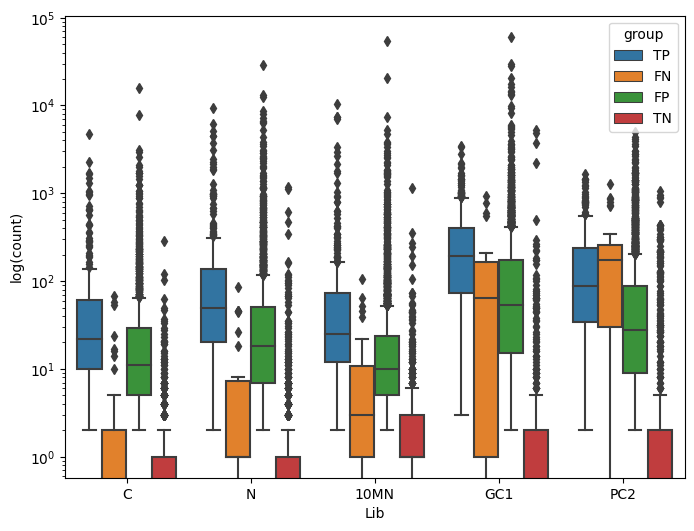

In [43]:
alldf = pd.DataFrame()
for i in df2.columns:
    df_lib = pd.DataFrame([i]*len(df2))
    df_plot = pd.concat([df2[i].reset_index(drop=True), df1[i].reset_index(drop=True), df_lib], axis=1)
    df_plot.columns = ['count', 'group', 'lib']
    alldf = pd.concat([alldf, df_plot], axis=0, ignore_index=True)
    
plt.figure(figsize=(8, 6))
sns.boxplot(data=alldf, x='lib', y='count', hue='group')
plt.title('')
plt.xlabel('Lib')
plt.yscale('log')
plt.ylabel('log(count)')
plt.show()  

In [44]:
P = len(pos_csv)
P_ls = [1] * P

N = len(neg_csv)
N_ls = [0] * N

len_y_true = P + N
y_true = P_ls + N_ls
y_true_reverse = ([0] * P) + ([1] * N)

In [45]:
palette = ["#fee090", "#fdae61", "#d73027", "#4575b4", "#abd9e9"]

In [46]:
colors = {'C':"#fee090", 'N':"#fdae61", '10MN':"#d73027", 'GC1':"#4575b4", 'PC2':"#abd9e9"}

In [47]:
#### COUNT ####

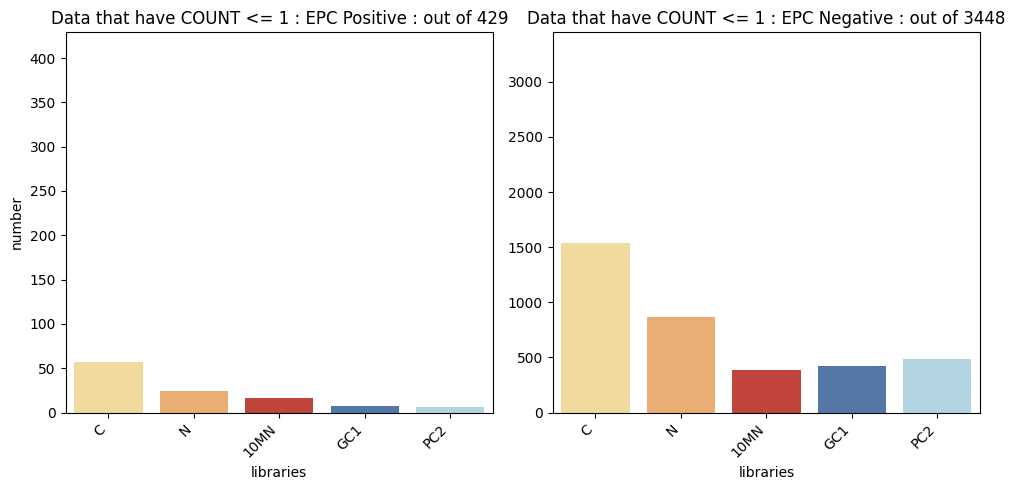

In [48]:
# FROM COUNT PROFILE, HOW MANY DATA THAT HAVE CAGE/GROCAP/PROCAP <= 1 

# Calculate column sums
pos_colsum = pos_mask.sum(axis=0)
neg_colsum = neg_mask.sum(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot positive barplot
sns.barplot(x=pos_colsum.index, y=pos_colsum.values, palette=palette, ax=ax1)
ax1.set_title('Data that have COUNT <= 1 : EPC Positive : out of ' + str(len(pos_mask)))
ax1.set_xlabel('libraries')
ax1.set_ylabel('number')
ax1.set_ylim(0, P)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# Plot negative barplot
sns.barplot(x=neg_colsum.index, y=neg_colsum.values, palette=palette, ax=ax2)
ax2.set_title('Data that have COUNT <= 1 : EPC Negative : out of ' + str(len(neg_mask)))
ax2.set_xlabel('libraries')
#ax2.set_ylabel('number')
ax2.set_ylim(0, N)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [49]:
#### PREDICTION ####

In [50]:
# confusion matrix on each object

def proba_confusion_matrix(df_pos, df_neg, threshold, P, N, mask):
    
    predpos = df_pos >= threshold
    TP = predpos.sum(axis=0)
    FN = P - TP
    
    cageneg_pos = df_pos == mask
    FN_cage = cageneg_pos.sum(axis=0)
    FN_pred = FN - FN_cage

    predneg = df_neg < threshold
    TN = predneg.sum(axis=0)  
    FP = N - TN
    
    cageneg_neg = df_neg == mask
    TN_cage = cageneg_neg.sum(axis=0)
    TN_pred = TN - TN_cage
    
    
    
    confusion = pd.DataFrame({'Lib': TP.index,
                              'TP': TP,
                              'FN': FN,
                              'TN': TN,
                              'FP': FP,
                              'FN_cage': FN_cage,
                              'FN_pred': FN_pred,
                              'TN_cage': TN_cage,
                              'TN_pred': TN_pred}
                              )
    
    return confusion


In [51]:
def precaision_recall(confusion):
    precision = confusion['TP'] / (confusion['TP'] + confusion['FP'])
    recall = confusion['TP'] / (confusion['TP'] + confusion['FN'])
    df = pd.DataFrame({'precision':precision,
                       'recall':recall})
    return(df)

In [52]:
def plot_confusion(confusion, save):
    confusion_melted = pd.melt(confusion, id_vars='Lib', var_name='Metric', value_name='Count')
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
    axes = axes.flatten()
    ylimit = [P, P, N, N, P, P, N, N]
    for i, column in enumerate(confusion.columns[1:]):  # Exclude the first column ('Lib')
        sns.barplot(x='Lib', y=column, data=confusion, ax=axes[i], palette=palette)
        axes[i].set_title(f'{column}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylim(0, ylimit[i])
    plt.tight_layout()
    if save != False:
        plt.savefig(save + '.pdf')
    plt.show()

In [53]:
def wrap_cfs_pr_plot(df_pos, df_neg, threshole, P, N, mask, save=False):
    cfs = proba_confusion_matrix(df_pos, df_neg, threshole, P, N, mask)
    pr = precaision_recall(cfs)
    plot_confusion(cfs, save)
    return(cfs, pr)

In [54]:
#### VARY PROBABILITY THRESHOLD ####

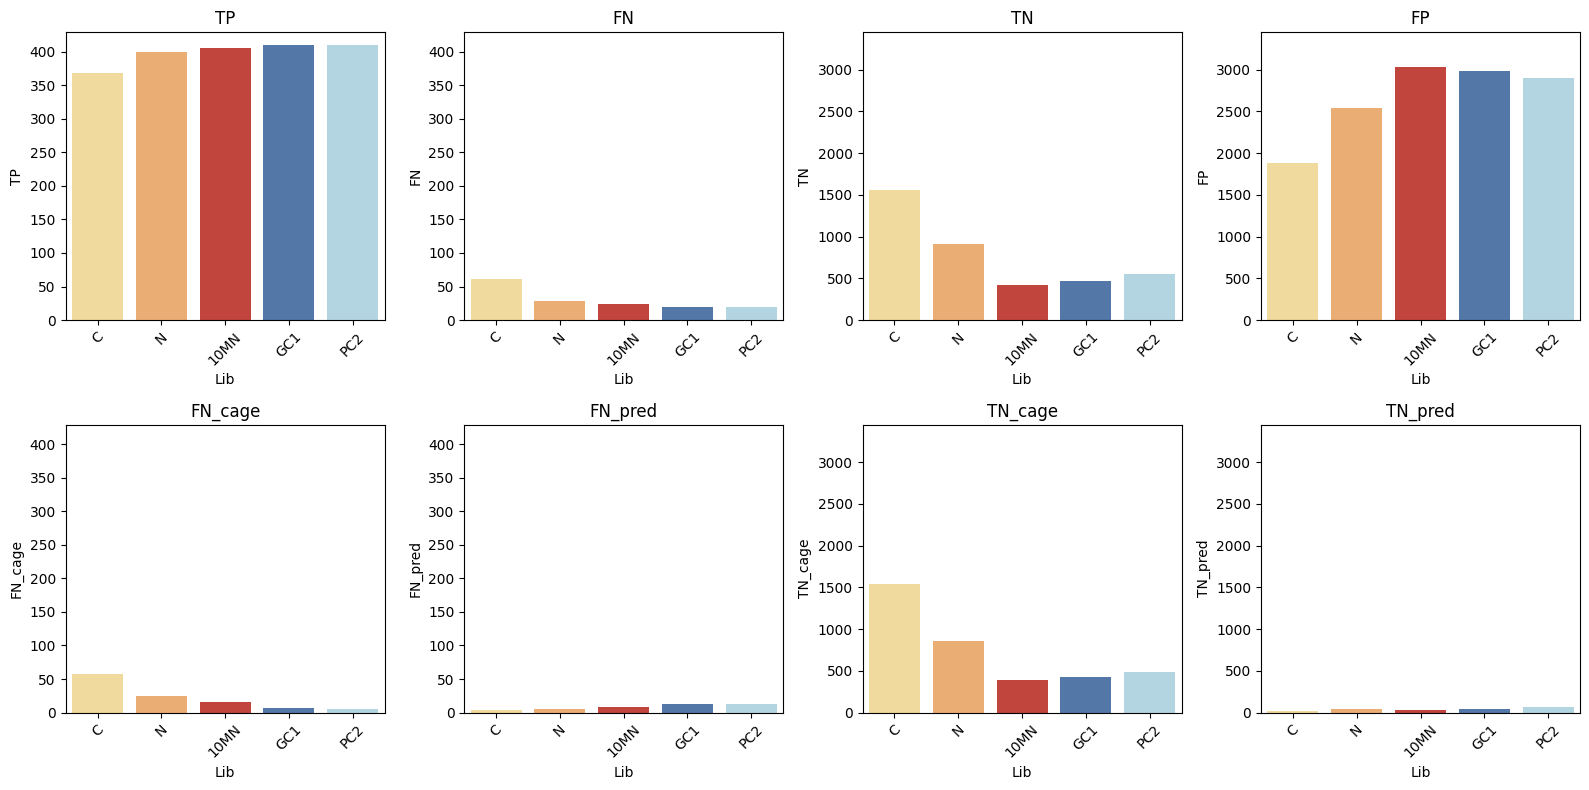

In [55]:
#### TRESHOLE=0.3 ####
cfs_yproba_maskm1_030, pr_yproba_maskm1_030 = wrap_cfs_pr_plot(pos_yproba_maskm1, neg_yproba_maskm1, 0.3, P, N, -1)

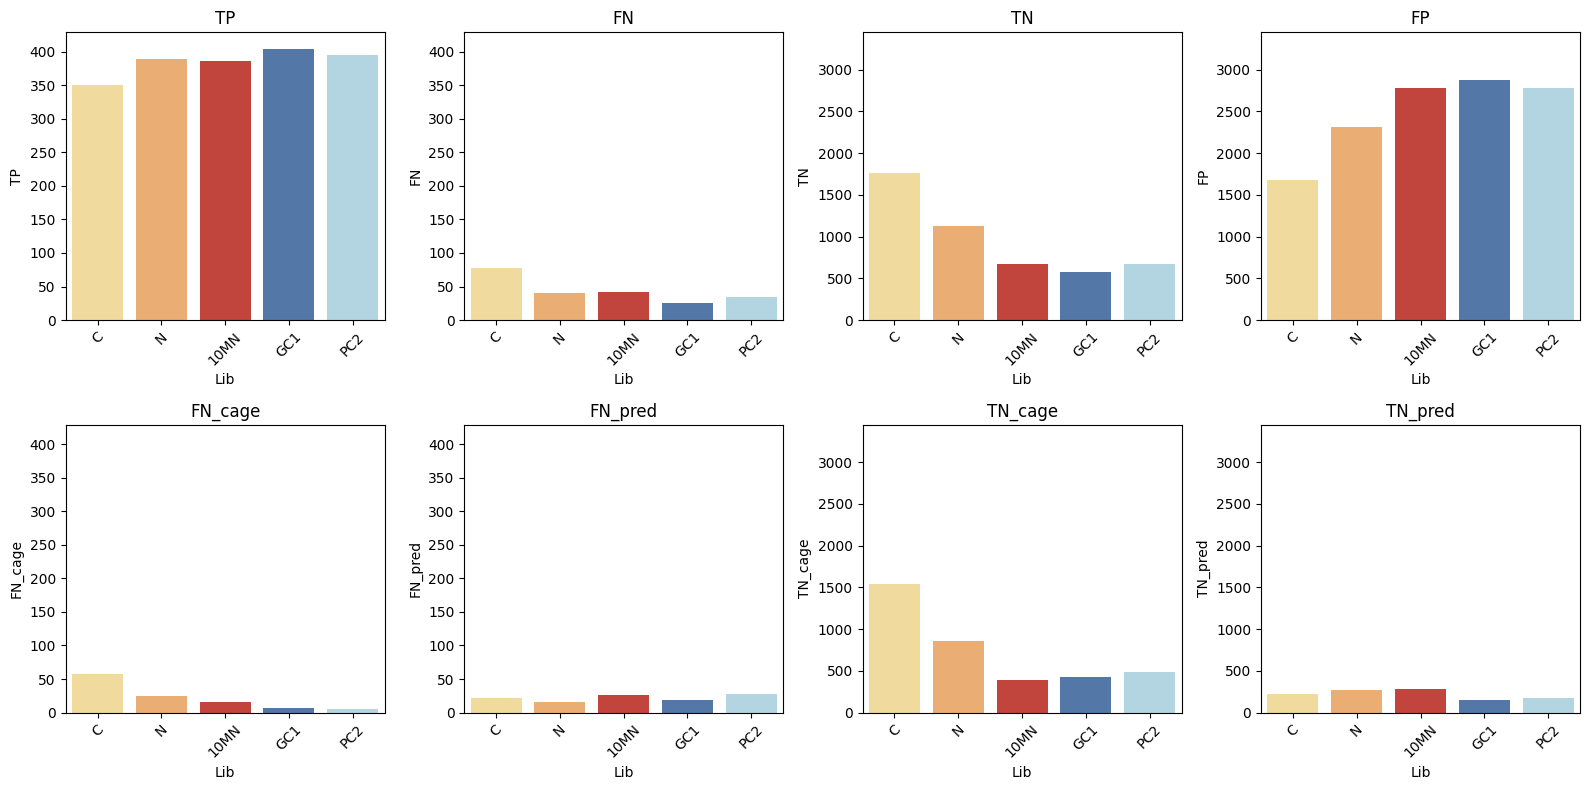

In [56]:
#### TRESHOLE=0.5 ####
cfs_yproba_maskm1_050, pr_yproba_maskm1_050 = wrap_cfs_pr_plot(pos_yproba_maskm1, neg_yproba_maskm1, 0.5, P, N, -1, 
                                                               save='4.EPC.confusionMatrix.barplot.prediction.050.poolSub')

In [57]:
pr_yproba_maskm1_050.transpose()

,C,N,10MN,GC1,PC2
precision,0.172651,0.143702,0.122314,0.123246,0.124409
recall,0.818182,0.906760,0.902098,0.941725,0.920746


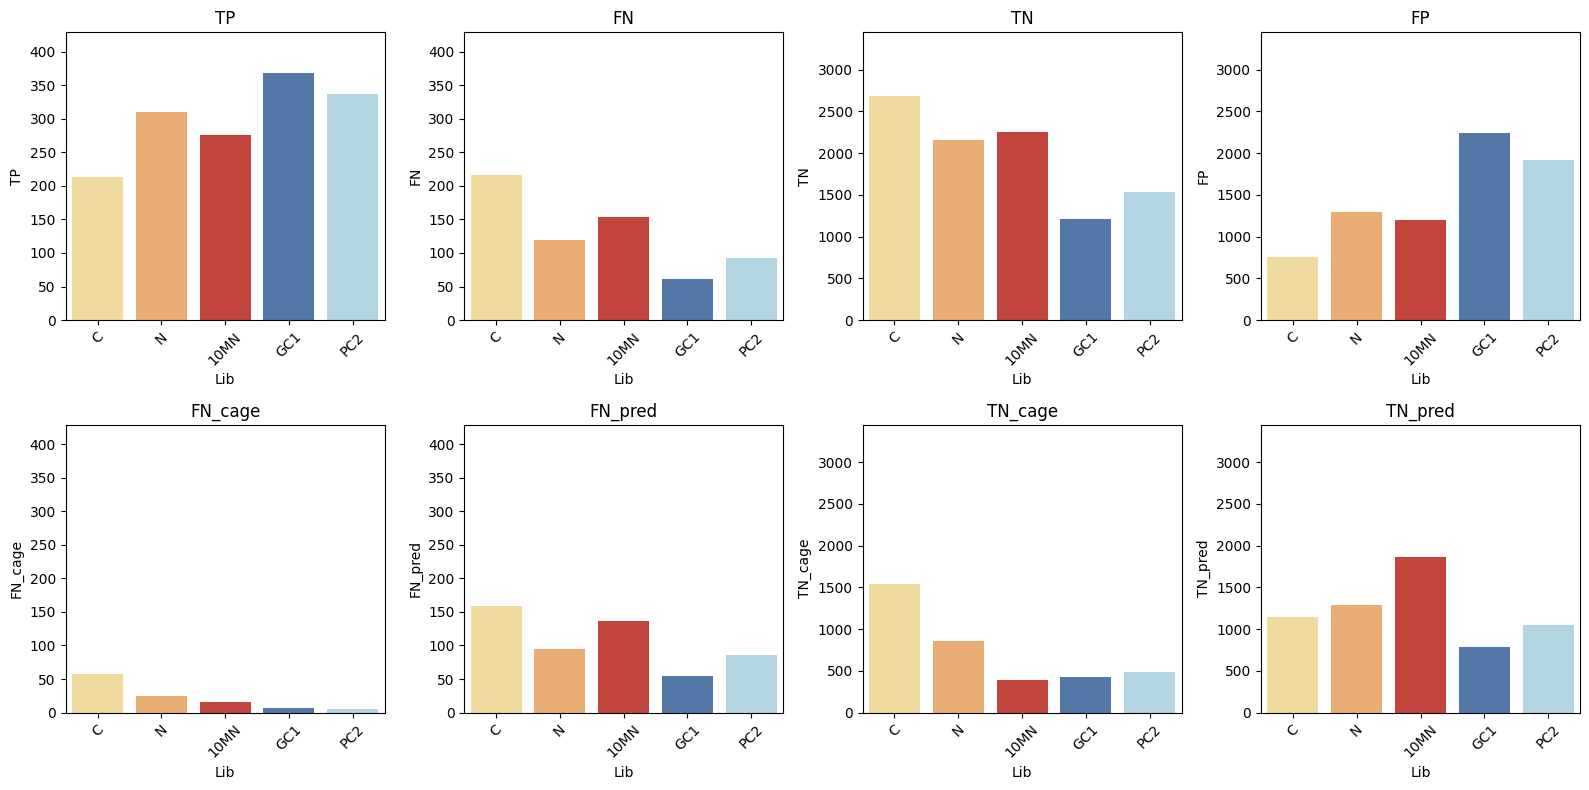

In [58]:
#### TRESHOLE=0.7 ####
cfs_yproba_maskm1_070, pr_yproba_maskm1_070 = wrap_cfs_pr_plot(pos_yproba_maskm1, neg_yproba_maskm1, 0.7, P, N, -1)

In [59]:
#### ROC AND AUCROC###

In [60]:
# Plot ROC Curve
def plot_roc_df(y_true, yproba, samples, save=False):
    plt.figure(figsize=(10, 5))
    for i in samples:
        fpr, tpr, _ = roc_curve(y_true, yproba[i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})', color=colors[i])
        
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    if save != False:
        plt.savefig(save + '.pdf')
    plt.show()
    #print(_)

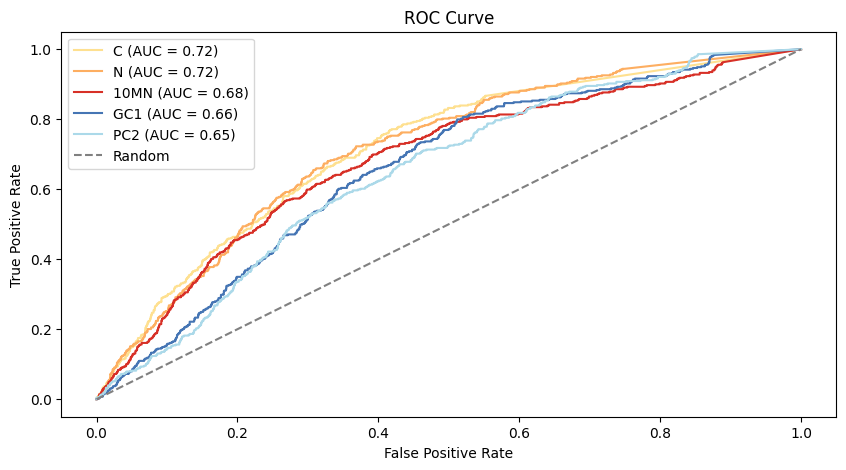

In [61]:
plot_roc_df(y_true, yproba_maskm1, prefer_order, save='4.EPC.ROC.curve.prediction.poolSub')

In [62]:
#### PR CURVE AND AUCPR ####

In [63]:
# Plot PR Curve

def plot_pr_df(y_true, yproba, samples, save=False):
    plt.figure(figsize=(10, 5))
    
    for i in samples:
        precision, recall, _ = precision_recall_curve(y_true, yproba[i])
        #print(precision)
        #print(recall)
        area_under_curve = auc(recall, precision)
        #print(area_under_curve)
        plt.plot(recall, precision, label=f'{i} (AUC = {area_under_curve:.2f})', color=colors[i])
        #avg_precision = average_precision_score(y_true, yproba[i])
        #plt.plot(recall, precision, label=f'{i} (AP = {avg_precision:.2f})', color=colors[i])
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    if save != False:
        plt.savefig(save + '.pdf')
    plt.show()

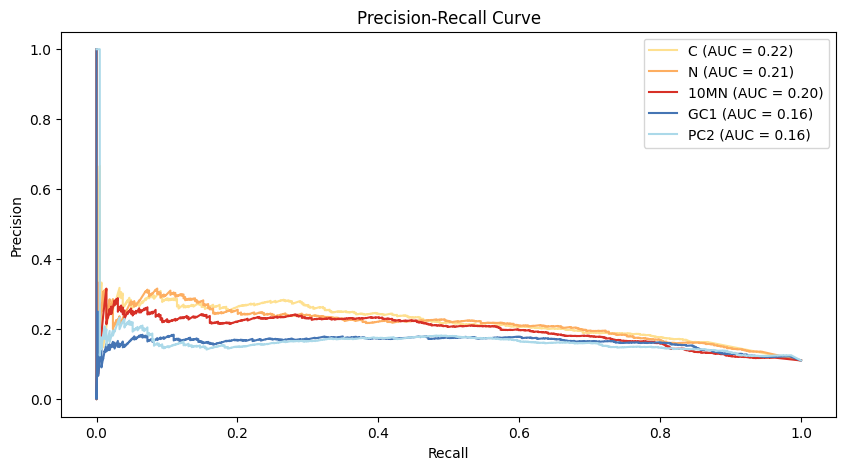

In [64]:
plot_pr_df(y_true, yproba_maskm1, prefer_order, save='4.EPC.PR.curve.prediction.poolSub')

In [65]:
#### DIVERGENT LOCI ####

In [66]:
def dl_confusion_matrix(df_pos, df_neg, threshole, P, N, mask, save=False):
    
    predpos = df_pos < threshole
    TP = predpos.sum(axis=0)
    FN = P - TP
    
    cageneg_pos = df_pos == mask
    FN_cage = cageneg_pos.sum(axis=0)
    FN_pred = FN - FN_cage

    predneg = df_neg >= threshole
    TN = predneg.sum(axis=0)
    FP = N - TN
    
    cageneg_neg = df_neg == mask
    TN_cage = cageneg_neg.sum(axis=0)
    TN_pred = TN - TN_cage
    
    confusion = pd.DataFrame({'Lib': TP.index,
                              'TP': TP,
                              'FN': FN,
                              'TN': TN,
                              'FP': FP,
                              'FN_cage': FN_cage,
                              'FN_pred': FN_pred,
                              'TN_cage': TN_cage,
                              'TN_pred': TN_pred})
    
    return(confusion)

In [67]:
def wrap_cfs_pr_plot_dl(df_pos, df_neg, threshole, P, N, mask, save=False):
    cfs = dl_confusion_matrix(df_pos, df_neg, threshole, P, N, mask)
    pr = precaision_recall(cfs)
    plot_confusion(cfs, save)
    return(cfs, pr)

In [68]:
#### VARY ABS DIRECTIONALITY THRESHOLD : 0.7, 0.8, 0.9 ####

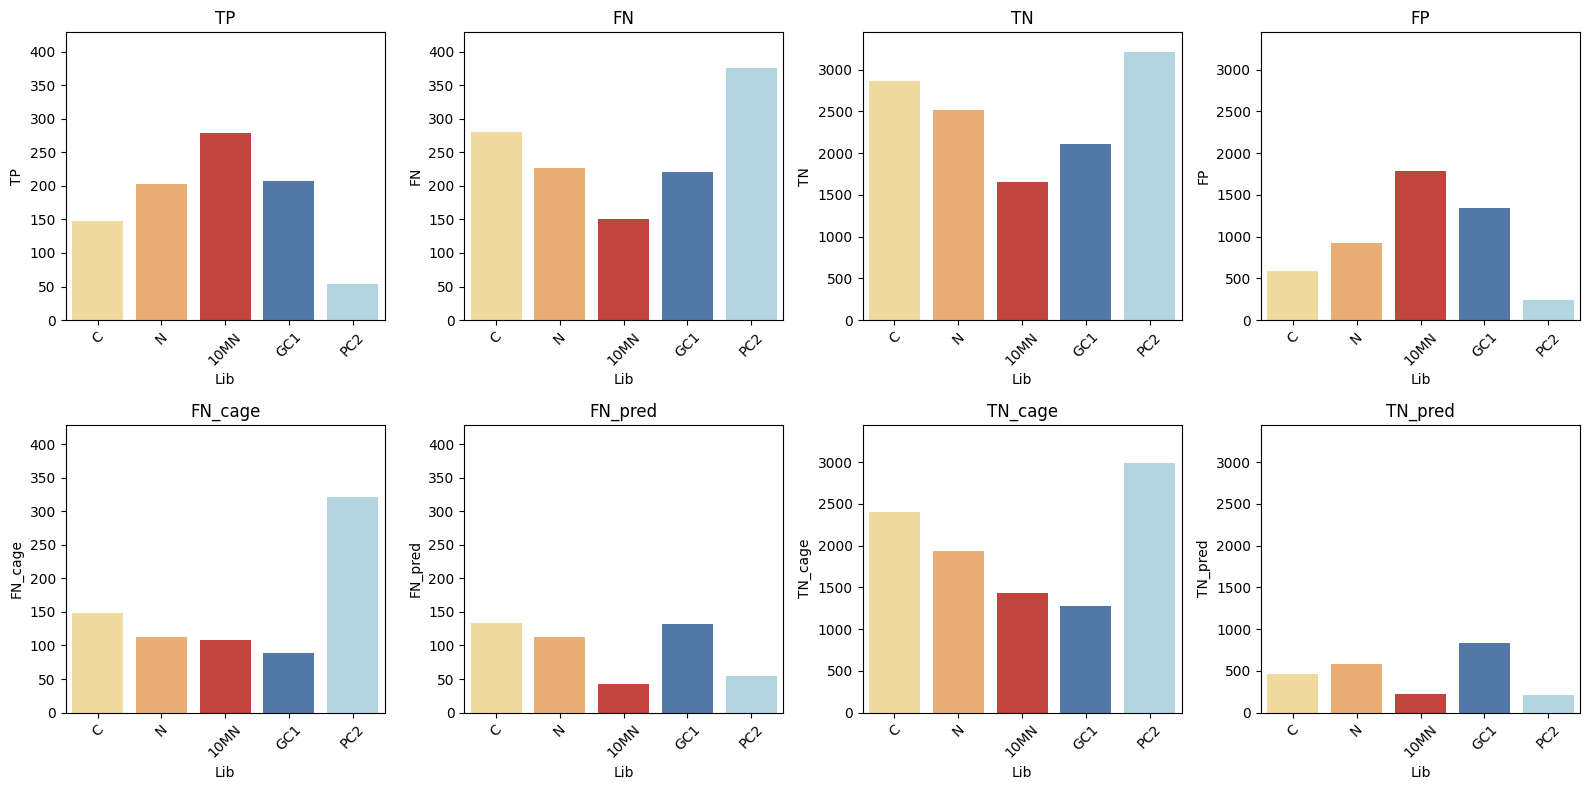

In [69]:
#### ABS DIRECTIONALITY < 0.7 ####
cfs_dl_070, pr_dl_070 = wrap_cfs_pr_plot_dl(pos_dl_absdir_mask1, neg_dl_absdir_mask1, 0.7, P, N, 1.1)

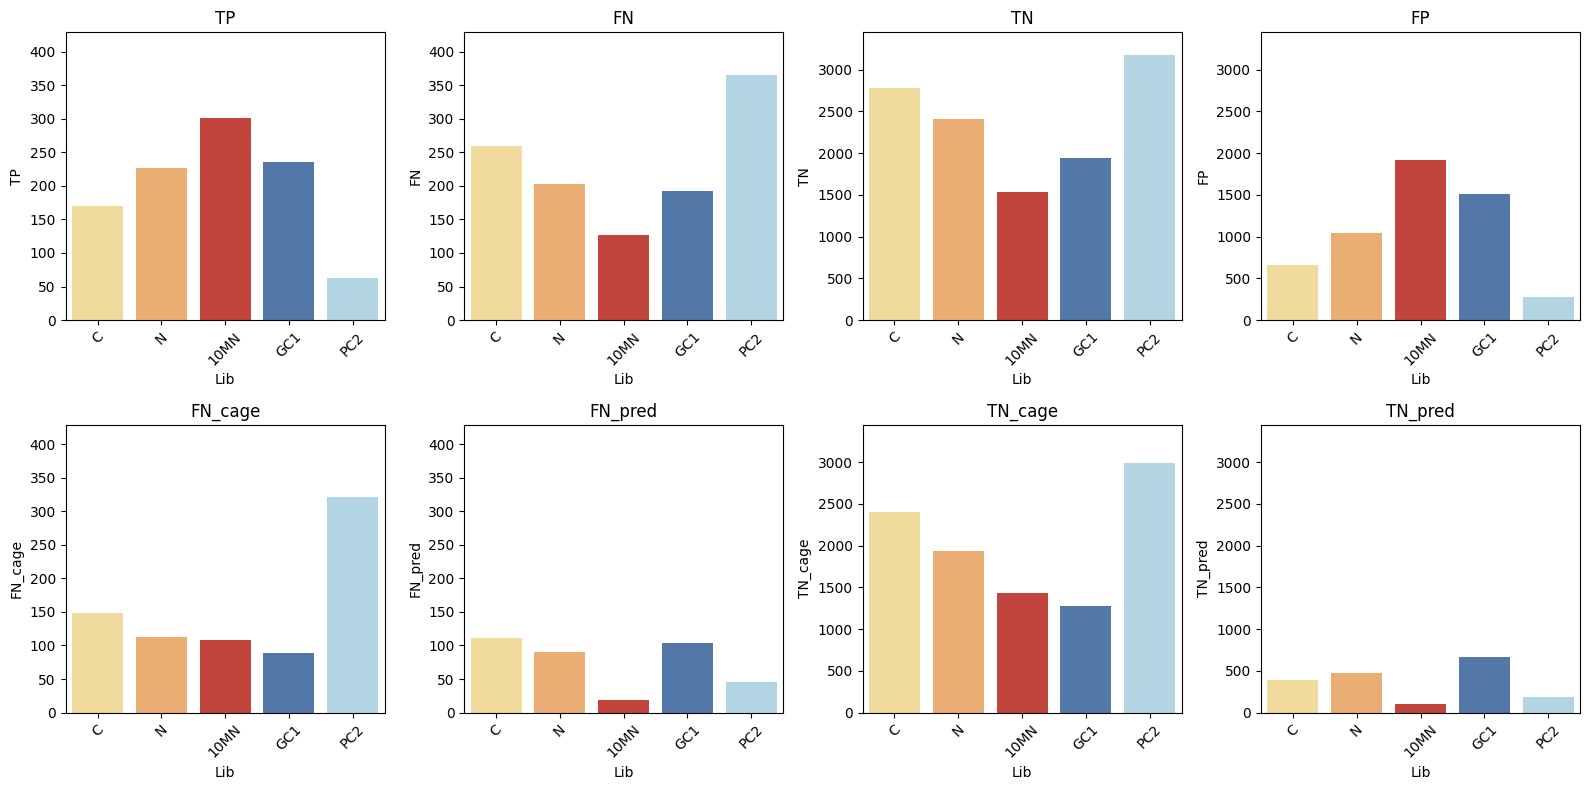

In [70]:
#### ABS DIRECTIONALITY < 0.8 ####
cfs_dl_080, pr_dl_080 = wrap_cfs_pr_plot_dl(pos_dl_absdir_mask1, neg_dl_absdir_mask1, 0.8, P, N, 1.1, 
                                            save='4.EPC.confusionMatrix.barplot.DL.080.poolSub')

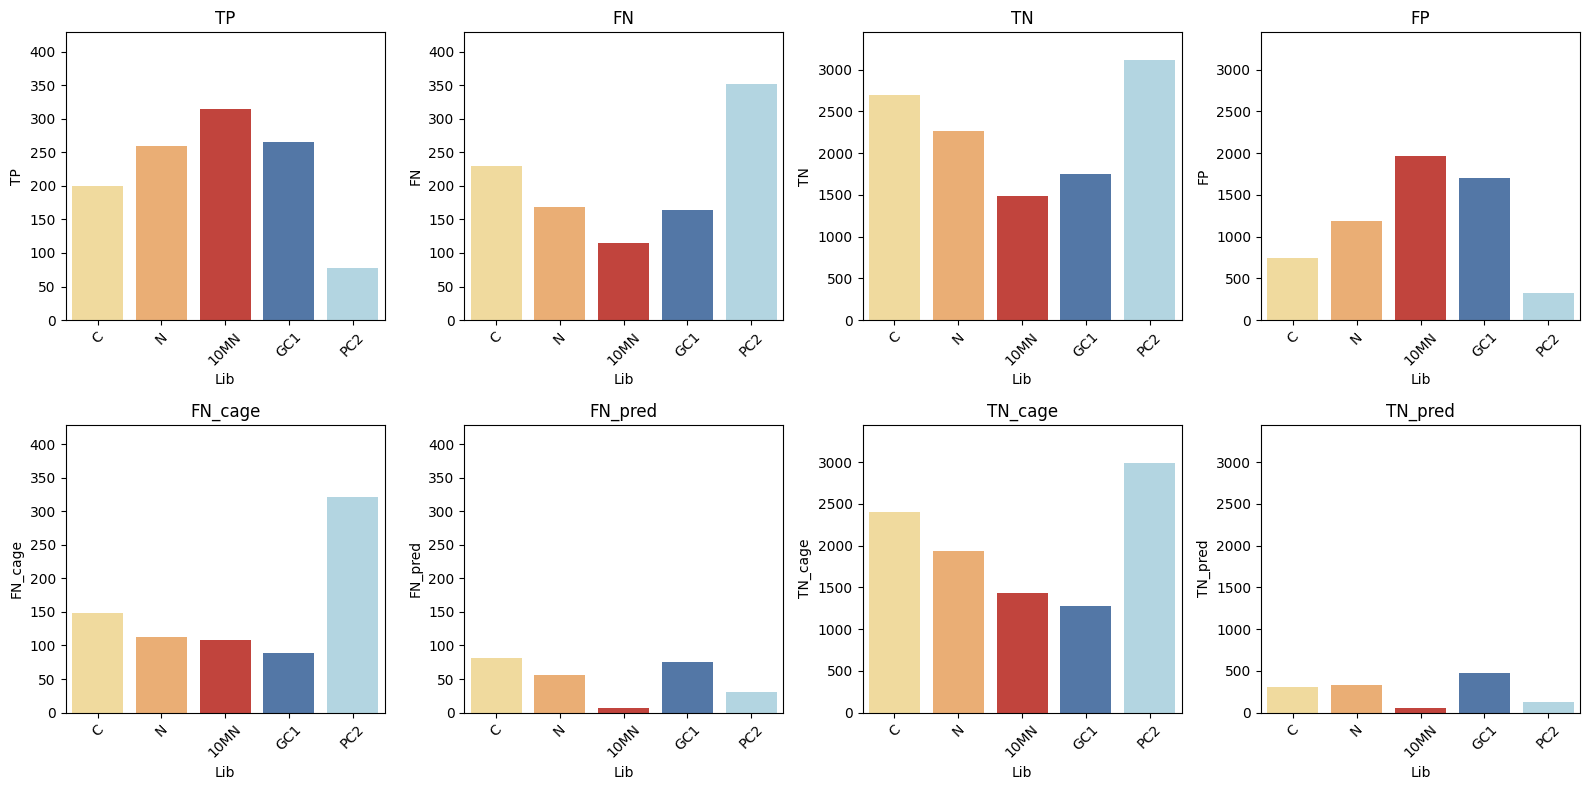

In [71]:
#### ABS DIRECTIONALITY < 0.9 ####
cfs_dl_090, pr_dl_090 = wrap_cfs_pr_plot_dl(pos_dl_absdir_mask1, neg_dl_absdir_mask1, 0.9, P, N, 1.1)

In [72]:
#### ROC CURVE AND AUCROC ####

In [73]:
# for dl, roc can be set param pos_label=0
# however, it doesn't work for pr
# set reverse label instead [0 for positive, 1 for negative]

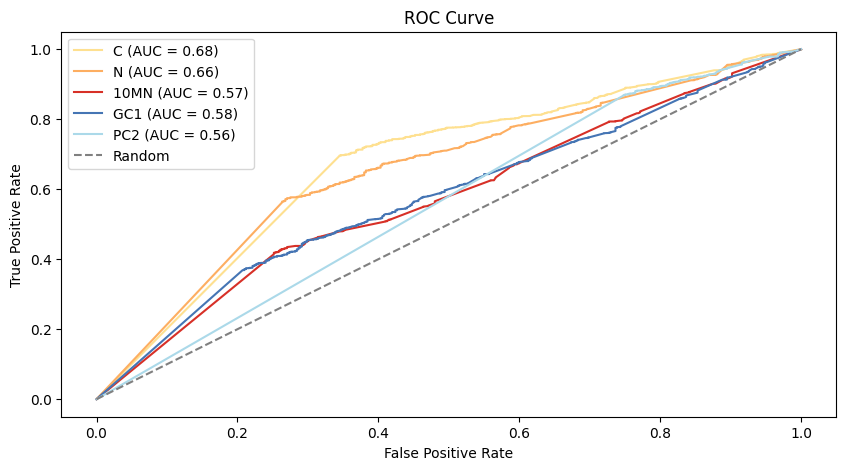

In [74]:
plot_roc_df(y_true_reverse, dl_absdir_mask1, prefer_order)

In [75]:
#### PR CURVE AND AUCPR ####

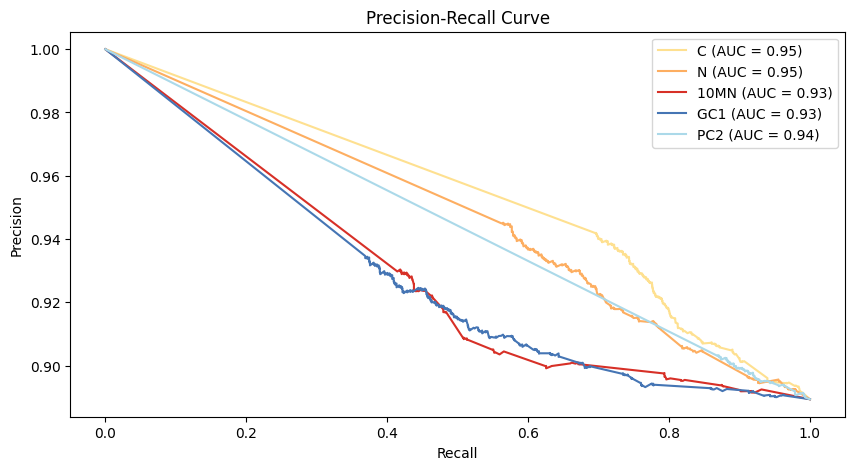

In [76]:
plot_pr_df(y_true_reverse, dl_absdir_mask1, prefer_order)

In [77]:
#### Bidir X Prediction ####

In [78]:
dlpos = pos_dl_absdir_mask1 < 0.8
predpos = pos_yproba_maskm1 >= 0.5

dlneg = neg_dl_absdir_mask1 < 0.8
predneg = neg_yproba_maskm1 >= 0.5

In [79]:
def counting_table(dl, pred):
    df = pd.DataFrame(index=dl.index, columns=dl.columns)
    df[:] = np.where((dl == True) & (pred == True), 'DL=TRUE & PRED=TRUE (T-T)',
                     np.where((dl == True) & (pred == False), 'DL=TRUE & PRED=FALSE (T-F)',
                              np.where((dl == False) & (pred == True), 'DL=FALSE & PRED=TRUE (F-T)', 'DL=FALSE & PRED=FALSE (F-F)')))
    return(df)

In [80]:
def count_occurrences(column):
    return column.value_counts()

In [81]:
ctpos = counting_table(dlpos, predpos)
result_pos = ctpos.apply(count_occurrences)
result_pos

,C,N,10MN,GC1,PC2
DL=FALSE & PRED=FALSE (F-F),49,19,18,15,28
DL=FALSE & PRED=TRUE (F-T),210,184,109,178,338
DL=TRUE & PRED=FALSE (T-F),29,21,24,10,6
DL=TRUE & PRED=TRUE (T-T),141,205,278,226,57


In [82]:
ctneg = counting_table(dlneg, predneg)
result_neg = ctneg.apply(count_occurrences)
result_neg

,C,N,10MN,GC1,PC2
DL=FALSE & PRED=FALSE (F-F),1472,832,338,334,622
DL=FALSE & PRED=TRUE (F-T),1312,1577,1195,1603,2555
DL=TRUE & PRED=FALSE (T-F),294,298,333,240,46
DL=TRUE & PRED=TRUE (T-T),370,741,1582,1271,225


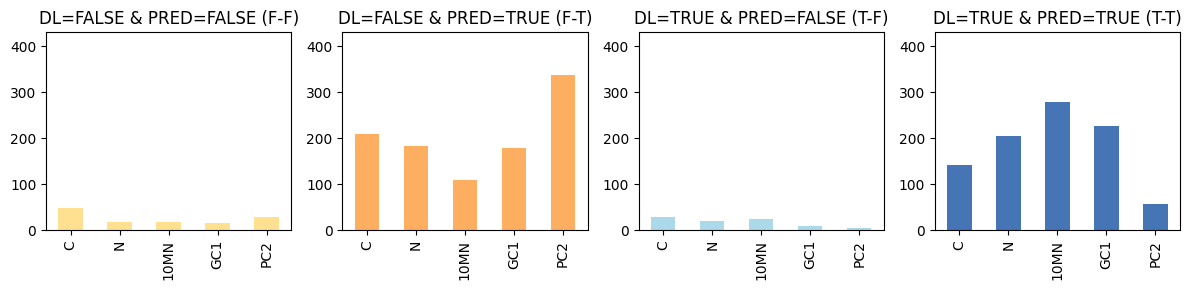

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

palettes = ["#fee090", "#fdae61", "#abd9e9", "#4575b4"]

# Convert the dictionaries to dataframes
df_pos = pd.DataFrame(result_pos)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

# Flatten the axes for easy indexing
axes = axes.flatten()

# Plot data for each category
for i, (category, ax) in enumerate(zip(df_pos.index, axes)):
    df_pos.loc[category].plot(kind='bar', ax=ax, color=palettes[i])
    ax.set_title(category)
    ax.set_ylim(0, 430)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

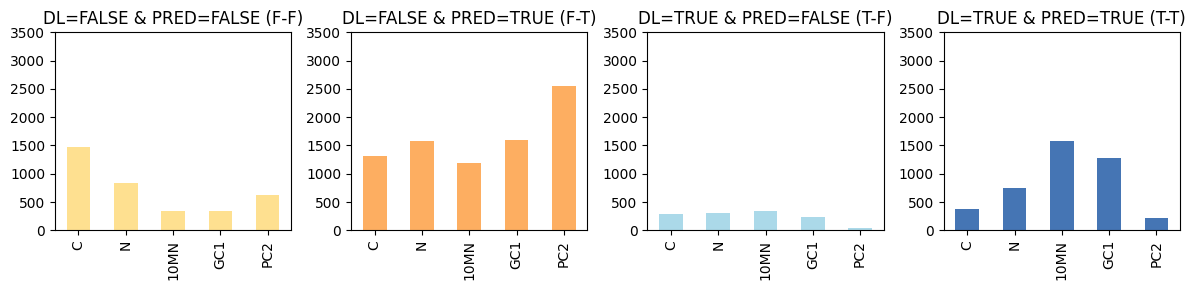

In [84]:
# Convert the dictionaries to dataframes
df_neg = pd.DataFrame(result_neg)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

# Flatten the axes for easy indexing
axes = axes.flatten()

# Plot data for each category
for i, (category, ax) in enumerate(zip(df_neg.index, axes)):
    df_neg.loc[category].plot(kind='bar', ax=ax, color=palettes[i])
    ax.set_title(category)
    ax.set_ylim(0, 3500)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

In [85]:
#import plotly.express as px

In [86]:
#pos_csv neg_dl_mask1 neg_yproba_maskm1

In [87]:
#neg_csv_slt =neg_csv[['txType', 'ovl.DHS', 'ovl.eQTL0.5']]

In [88]:
'''
import pandas as pd

df = pd.DataFrame(neg_csv_slt)

# Create an empty dictionary to store mappings
mappings = {}

# Factorize each column and store mappings
for col in df.columns:
    factorized, mapping = pd.factorize(df[col])
    mappings[col] = dict(zip(mapping, range(1, len(mapping) + 1)))  # Create a mapping dictionary
    df[col] = factorized + 1  # Factorize and add 1 to start from 1 instead of 0

# Display the modified DataFrame
print("Modified DataFrame:")
print(df)

# Display the mappings
print("\nMappings:")
for col, mapping in mappings.items():
    print(f"{col}: {mapping}")
'''

'\nimport pandas as pd\n\ndf = pd.DataFrame(neg_csv_slt)\n\n# Create an empty dictionary to store mappings\nmappings = {}\n\n# Factorize each column and store mappings\nfor col in df.columns:\n    factorized, mapping = pd.factorize(df[col])\n    mappings[col] = dict(zip(mapping, range(1, len(mapping) + 1)))  # Create a mapping dictionary\n    df[col] = factorized + 1  # Factorize and add 1 to start from 1 instead of 0\n\n# Display the modified DataFrame\nprint("Modified DataFrame:")\nprint(df)\n\n# Display the mappings\nprint("\nMappings:")\nfor col, mapping in mappings.items():\n    print(f"{col}: {mapping}")\n'

In [89]:
'''
neg_csv_slt['dl_N'] = neg_dl_mask1['N']
neg_csv_slt['pred_N'] = neg_yproba_maskm1['N']
neg_csv_slt
'''

"\nneg_csv_slt['dl_N'] = neg_dl_mask1['N']\nneg_csv_slt['pred_N'] = neg_yproba_maskm1['N']\nneg_csv_slt\n"

In [90]:
'''
# Create the chart:
fig = px.parallel_coordinates(
    df, 
    color="pred_N", 
    labels={"dl_N":"dl_N", "pred_N":"pred_N", "txType": "txType","ovl.DHS": "ovl.DHS", "ovl.eQTL0.5h": "ovl.eQTL0.5", },)
    #color_continuous_scale=px.colors.diverging.Tealrose,
    #color_continuous_midpoint=2)

# Hide the color scale that is useless in this case
#fig.update_layout(coloraxis_showscale=False)

# Show the plot
fig.show()
'''

'\n# Create the chart:\nfig = px.parallel_coordinates(\n    df, \n    color="pred_N", \n    labels={"dl_N":"dl_N", "pred_N":"pred_N", "txType": "txType","ovl.DHS": "ovl.DHS", "ovl.eQTL0.5h": "ovl.eQTL0.5", },)\n    #color_continuous_scale=px.colors.diverging.Tealrose,\n    #color_continuous_midpoint=2)\n\n# Hide the color scale that is useless in this case\n#fig.update_layout(coloraxis_showscale=False)\n\n# Show the plot\nfig.show()\n'